### Imports

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

### paths

In [2]:
REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
DOCS_DIR = REPO_ROOT / "docs"
DOCS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROCESSED_DIR / "features_nbhd_day_511.parquet"

print("FEATURES_PATH:", FEATURES_PATH)

FEATURES_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\features_nbhd_day_511.parquet


### Load feature table

In [3]:
df = pd.read_parquet(FEATURES_PATH)

print("Loaded shape:", df.shape)
print(df.columns.tolist()[:20])
df.head(2)

Loaded shape: (691408, 114)
['area_id', 'area_name', 'date', 'collisions', 'nbhd_id', 'ksi_collisions', 'ksi_fatal_collisions', 'ksi_serious_collisions', 'ksi_fatal_victims', 'ksi_victim_count', 'ksi_weighted_score', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'freeze_day', 'snow_day', 'rain_day']


,area_id,area_name,date,collisions,nbhd_id,ksi_collisions,ksi_fatal_collisions,ksi_serious_collisions,ksi_fatal_victims,ksi_victim_count,...,road_construction_severity_weighted_halo_lag7,road_construction_severity_weighted_halo_roll7_sum,road_construction_severity_weighted_halo_roll14_sum,road_construction_full_closure_count_halo_lag1,road_construction_full_closure_count_halo_lag7,road_construction_full_closure_count_halo_roll7_sum,road_construction_full_closure_count_halo_roll14_sum,dow,month,year
0,2502213,West Humber-Clairville,2014-01-08,1,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,2,1,2014
1,2502213,West Humber-Clairville,2014-01-09,4,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,3,1,2014


### Normalize key types

In [4]:
df["date"] = pd.to_datetime(df["date"])
df["nbhd_id"] = pd.to_numeric(df["nbhd_id"], errors="coerce").astype(int)

print(df[["date", "nbhd_id"]].dtypes)
print("Date range:", df["date"].min(), "to", df["date"].max())

date       datetime64[ms]
nbhd_id             int64
dtype: object
Date range: 2014-01-08 00:00:00 to 2025-12-31 00:00:00


### Build citywide collision totals and surge label

In [5]:
city_daily = (
    df.groupby("date", as_index=False)
      .agg(city_collisions=("collisions", "sum"))
      .sort_values("date")
)

print("city_daily shape:", city_daily.shape)
city_daily.head()

city_daily shape: (4376, 2)


,date,city_collisions
0,2014-01-08,207
1,2014-01-09,222
2,2014-01-10,155
3,2014-01-11,117
4,2014-01-12,66


### Merge city totals back into row-level dataset

In [6]:
df = df.merge(city_daily, on="date", how="left")

print("Shape after city merge:", df.shape)
df[["date", "nbhd_id", "collisions", "city_collisions"]].head()

Shape after city merge: (691408, 115)


,date,nbhd_id,collisions,city_collisions
0,2014-01-08,1,1,207
1,2014-01-09,1,4,222
2,2014-01-10,1,3,155
3,2014-01-11,1,2,117
4,2014-01-12,1,0,66


### Define feature exclusion list

In [7]:
drop_cols = {
    # identifiers
    "date",
    "nbhd_id",
    "area_id",
    "AREA_ID",
    "area_name",
    "AREA_NAME",
    "geometry",

    # target leakage / same-day direct signal
    "collisions",
    "city_collisions",

    # same-day KSI counts can leak same-day severity
    "ksi_collisions",
    "ksi_weighted_score",
    "ksi_fatal_collisions",
    "ksi_serious_collisions",
    "ksi_fatal_victims",
    "ksi_victim_count",
}

X_cols = [c for c in df.columns if c not in drop_cols]

print("Number of candidate features:", len(X_cols))
print(X_cols[:30])

Number of candidate features: 103
['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'freeze_day', 'snow_day', 'rain_day', 'road_events_count', 'road_events_severity_weighted', 'road_events_full_closure_count', 'road_construction_count', 'road_construction_severity_weighted', 'road_construction_full_closure_count', 'collisions_lag1', 'collisions_lag7', 'collisions_lag14', 'ksi_collisions_lag1', 'ksi_collisions_lag7', 'ksi_collisions_lag14', 'ksi_weighted_score_lag1', 'ksi_weighted_score_lag7', 'ksi_weighted_score_lag14', 'road_events_count_lag1', 'road_events_count_lag7', 'road_events_count_lag14', 'road_events_severity_weighted_lag1', 'road_events_severity_weighted_lag7', 'road_events_severity_weighted_lag14']


#### Note on Operational Task: This model is designed as an End-of-Day Next-Day Surge Forecast. It assumes that at the close of day t, all observed weather and road disruption data for that day are finalized and available to predict the probability of a citywide collision surge on day t+1.

### Helper functions

In [8]:
def compute_metrics(y_true, y_prob, train_days=None):
    from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

    metrics = {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Brier-Score": brier_score_loss(y_true, y_prob),
        "Test_Days": len(y_true)
    }

    if train_days is not None:
        metrics["Train_Days"] = train_days

    return metrics


def train_eval_citywide_surge(data, split_date, label_name):
    # 1. Aggregation Logic
    agg_dict = {c: 'mean' for c in X_cols}

    # Sum for volumes
    count_features = [c for c in X_cols if any(word in c for word in ['count', 'collisions', 'weighted'])]
    for c in count_features:
        agg_dict[c] = 'sum'

    # Max for binary indicators
    indicator_features = [c for c in X_cols if any(word in c for word in ['is_', 'disrupted', 'pressure'])]
    for c in indicator_features:
        agg_dict[c] = 'max'

    # FIX: Explicitly add 'collisions' to the aggregation so it survives the groupby
    # We use a copy to prevent fragmentation warnings
    daily_df = data.groupby("date").agg({**agg_dict, "collisions": "sum"}).sort_values("date").copy()
    daily_df = daily_df.reset_index()

    # Now 'collisions' exists in daily_df, so shifting will work
    daily_df['target_surge_tomorrow'] = daily_df['collisions'].shift(-1)

    # Drop the last row as it has no "tomorrow" target
    daily_df = daily_df.dropna(subset=['target_surge_tomorrow']).copy()

    # 3. Define the Surge Label on the FUTURE target
    # Compute threshold on training portion only to avoid leakage
    train_temp = daily_df[daily_df["date"] < split_date]
    threshold = np.quantile(train_temp["target_surge_tomorrow"], 0.90)

    daily_df['y'] = (daily_df['target_surge_tomorrow'] >= threshold).astype(int)

    # 4. Final Splits
    train = daily_df[daily_df["date"] < split_date].copy()
    test = daily_df[daily_df["date"] >= split_date].copy()

    pretty_label = {
        "full_history_split": "Full-History Split",
        "recent_era_split_2022plus": "Recent-Era Split (2022+)"
    }.get(label_name, label_name)

    print(f"\n===== {pretty_label} (NEXT-DAY FORECAST) =====")
    print(f"Surge threshold (Tomorrow's Collisions): {threshold}")

    """model = LGBMClassifier(
        objective="binary",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        scale_pos_weight=(len(train) - train['y'].sum()) / train['y'].sum(),
        random_state=42,
        n_jobs=-1
    )"""
    # Optimization for small sample sizes (Recent-Era Split)
    if label_name == "recent_era_split_2022plus":
        n_est, n_leaves = 100, 15  # reduced from 300/31 to limit overfitting on ~730 train days
    else:
        n_est, n_leaves = 300, 31

    model = LGBMClassifier(
        n_estimators=n_est,
        num_leaves=n_leaves,
        learning_rate=0.05,
        scale_pos_weight=(len(train) - train['y'].sum()) / train['y'].sum(),
        random_state=42,
        verbose=-1 # Silences excessive warnings
    )

    model.fit(train[X_cols], train['y'])
    test_proba = model.predict_proba(test[X_cols])[:, 1]

    metrics = compute_metrics(test['y'], test_proba, train_days=len(train))
    fi = pd.DataFrame({"feature": X_cols, "importance": model.feature_importances_})

    # Return date and the ACTUAL tomorrow's collisions for validation in Notebook 12
    pred = test[["date", "target_surge_tomorrow"]].copy()
    pred["y_true"] = test['y'].values
    pred["surge_proba"] = test_proba

    return model, metrics, pred, fi.sort_values("importance", ascending=False)

### Evaluation A : Full-history split
#### Run full-history evaluation

In [9]:
split_date_full = pd.Timestamp("2024-01-01")

model_full, metrics_full, pred_full, fi_full = train_eval_citywide_surge(
    data=df,
    split_date=split_date_full,
    label_name="full_history_split"
)

print("\nFull-history metrics:")
print(metrics_full)
fi_full.head(20)


===== Full-History Split (NEXT-DAY FORECAST) =====
Surge threshold (Tomorrow's Collisions): 208.0

Full-history metrics:
{'ROC-AUC': 0.7551218161683279, 'PR-AUC': 0.24478126075965914, 'Brier-Score': 0.06637580808860462, 'Test_Days': 730, 'Train_Days': 3645}


,feature,importance
5,wspd,907
15,collisions_lag1,834
17,collisions_lag14,817
42,collisions_roll7_sum,792
43,collisions_roll14_sum,771
16,collisions_lag7,703
44,collisions_roll30_sum,659
1,tmin,588
2,tmax,564
3,prcp,435


### Evaluation B : Recent-era split (2022+)
#### Evaluation B — Recent-era split (2022+)

In [10]:
df_recent = df[df["date"] >= pd.Timestamp("2022-01-01")].copy()

print("Recent-era shape:", df_recent.shape)
print("Recent-era date range:", df_recent["date"].min(), "to", df_recent["date"].max())

Recent-era shape: (230838, 115)
Recent-era date range: 2022-01-01 00:00:00 to 2025-12-31 00:00:00


### Run recent-era evaluation

In [11]:
split_date_recent = pd.Timestamp("2024-01-01")

model_recent, metrics_recent, pred_recent, fi_recent = train_eval_citywide_surge(
    data=df_recent,
    split_date=split_date_recent,
    label_name="recent_era_split_2022plus"
)

print("\nRecent-era metrics:")
print(metrics_recent)
fi_recent.head(20)


===== Recent-Era Split (2022+) (NEXT-DAY FORECAST) =====
Surge threshold (Tomorrow's Collisions): 190.0

Recent-era metrics:
{'ROC-AUC': 0.6764401963316972, 'PR-AUC': 0.2947229248617225, 'Brier-Score': 0.15695839847271262, 'Test_Days': 730, 'Train_Days': 730}


,feature,importance
15,collisions_lag1,122
42,collisions_roll7_sum,113
2,tmax,94
1,tmin,94
44,collisions_roll30_sum,90
43,collisions_roll14_sum,89
0,tavg,84
100,dow,83
5,wspd,79
16,collisions_lag7,71


### Comparison outputs

#### Compare metrics side by side

In [12]:
metrics_df = pd.DataFrame([
    {"evaluation": "full_history_split", **metrics_full},
    {"evaluation": "recent_era_split_2022plus", **metrics_recent},
])

print(metrics_df)

                  evaluation   ROC-AUC    PR-AUC  Brier-Score  Test_Days  \
0         full_history_split  0.755122  0.244781     0.066376        730   
1  recent_era_split_2022plus  0.676440  0.294723     0.156958        730   

   Train_Days  
0        3645  
1         730  


#### Note on Test-Day Count
#### The test set contains **730 days** rather than 731 because the target is defined as `target_surge_tomorrow = collisions.shift(-1)`.
#### This forward shift removes the final available date, since it has no observable `t+1` outcome.

#### Save predictions

In [13]:
pred_all = pd.concat([pred_full, pred_recent], ignore_index=True)

pred_path = PROCESSED_DIR / "pred_citywide_surge_511.parquet"
pred_all.to_parquet(pred_path, index=False)

print("Saved predictions:", pred_path)
print(pred_all.shape)

Saved predictions: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\pred_citywide_surge_511.parquet
(1460, 4)


#### Save metrics

In [14]:
metrics_path_csv = DOCS_DIR / "citywide_surge_511_metrics.csv"
metrics_path_json = DOCS_DIR / "citywide_surge_511_metrics.json"

metrics_df.to_csv(metrics_path_csv, index=False)

with open(metrics_path_json, "w") as f:
    json.dump(metrics_df.to_dict(orient="records"), f, indent=2)

print("Saved metrics CSV:", metrics_path_csv)
print("Saved metrics JSON:", metrics_path_json)

Saved metrics CSV: C:\code\pyspark-playground\Covercheck-Toronto\docs\citywide_surge_511_metrics.csv
Saved metrics JSON: C:\code\pyspark-playground\Covercheck-Toronto\docs\citywide_surge_511_metrics.json


#### Save feature importances

In [15]:
fi_full_path = DOCS_DIR / "citywide_surge_511_feature_importance_full.csv"
fi_recent_path = DOCS_DIR / "citywide_surge_511_feature_importance_recent.csv"

fi_full.to_csv(fi_full_path, index=False)
fi_recent.to_csv(fi_recent_path, index=False)

print("Saved full-history FI:", fi_full_path)
print("Saved recent-era FI:", fi_recent_path)

Saved full-history FI: C:\code\pyspark-playground\Covercheck-Toronto\docs\citywide_surge_511_feature_importance_full.csv
Saved recent-era FI: C:\code\pyspark-playground\Covercheck-Toronto\docs\citywide_surge_511_feature_importance_recent.csv


#### Quick inspection of top features

In [16]:
print("\nTop 20 features — Full History")
display(fi_full.head(20))

print("\nTop 20 features — Recent Era")
display(fi_recent.head(20))


Top 20 features — Full History


,feature,importance
5,wspd,907
15,collisions_lag1,834
17,collisions_lag14,817
42,collisions_roll7_sum,792
43,collisions_roll14_sum,771
16,collisions_lag7,703
44,collisions_roll30_sum,659
1,tmin,588
2,tmax,564
3,prcp,435



Top 20 features — Recent Era


,feature,importance
15,collisions_lag1,122
42,collisions_roll7_sum,113
2,tmax,94
1,tmin,94
44,collisions_roll30_sum,90
43,collisions_roll14_sum,89
0,tavg,84
100,dow,83
5,wspd,79
16,collisions_lag7,71


### See whether 511 features actually show up in importance

In [17]:
# Updated to include halo and normalized 511 features [cite: 2449, 2461]
road_features_full = fi_full[fi_full["feature"].str.contains("road_|halo|disrupted", case=False, na=False)].head(20)
road_features_recent = fi_recent[fi_recent["feature"].str.contains("road_|halo|disrupted", case=False, na=False)].head(20)

print("Top road/spatial features in full-history:")
display(road_features_full)

print("Top road-related features in recent-era model:")
display(road_features_recent)

Top road/spatial features in full-history:


,feature,importance
70,road_construction_total_pressure_roll14_sum,6
12,road_construction_count,5
10,road_events_severity_weighted,0
24,road_events_count_lag1,0
25,road_events_count_lag7,0
9,road_events_count,0
13,road_construction_severity_weighted,0
11,road_events_full_closure_count,0
14,road_construction_full_closure_count,0
38,road_construction_severity_weighted_lag14,0


Top road-related features in recent-era model:


,feature,importance
55,road_construction_count_roll14_sum,10
56,road_construction_count_roll30_sum,3
12,road_construction_count,2
69,road_construction_total_pressure,1
35,road_construction_count_lag14,1
10,road_events_severity_weighted,0
9,road_events_count,0
14,road_construction_full_closure_count,0
13,road_construction_severity_weighted,0
38,road_construction_severity_weighted_lag14,0


### Visual Validation of Signal Impact

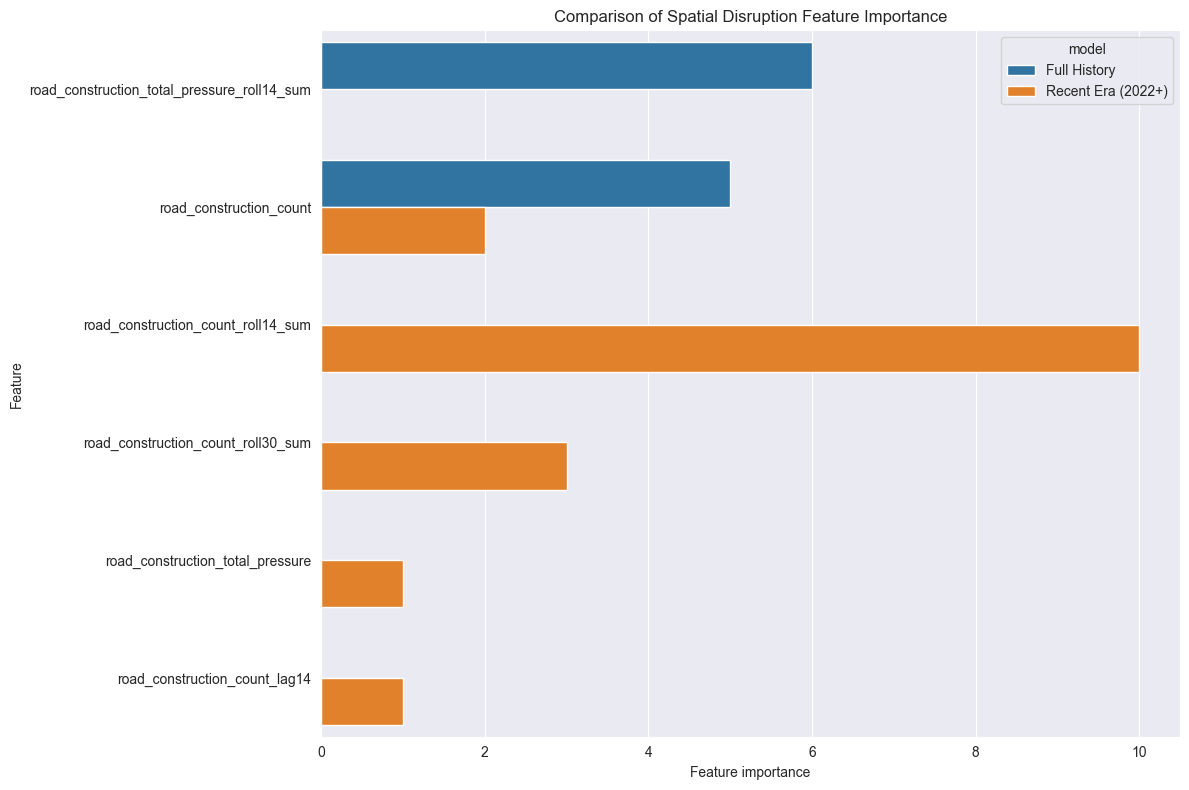

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# comparing top road / spatial features for both models
fi_full_plot = fi_full.copy()
fi_recent_plot = fi_recent.copy()

fi_full_plot["model"] = "Full History"
fi_recent_plot["model"] = "Recent Era (2022+)"

road_pattern = r"road_|halo|disrupted|pressure"

# Keep only road/spatial features with strictly positive importance
road_fi = pd.concat([
    fi_full_plot[
        fi_full_plot["feature"].str.contains(road_pattern, case=False, na=False)
        & (fi_full_plot["importance"] > 0)
    ].head(10),
    fi_recent_plot[
        fi_recent_plot["feature"].str.contains(road_pattern, case=False, na=False)
        & (fi_recent_plot["importance"] > 0)
    ].head(10)
], ignore_index=True)

if not road_fi.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(data=road_fi, x="importance", y="feature", hue="model")
    plt.title("Comparison of Spatial Disruption Feature Importance")
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No road/spatial features had positive importance in either model.")

#### Interpretation Note: Spatial Disruption & Survivorship Bias
#### The primary spatial signal identified by the citywide model is **not a single binary disruption flag**, but rather a small group of **construction-count and pressure-based disruption proxies**. In particular, the road-related features that surface with non-zero importance are:
#### - `road_construction_count`
#### - `road_construction_count_roll14_sum`
#### - `road_construction_count_roll30_sum`
#### - `road_construction_total_pressure`
#### - `road_construction_total_pressure_roll14_sum`

#### This suggests that, at the citywide level, the model responds more to the **aggregate intensity and persistence of construction activity** than to a simple yes/no indicator of disruption.
#### However, users must account for **survivorship bias** in the underlying 511 data. Because this layer was derived from a **2026 API snapshot expanded backward** using `StartDate` and `PlannedEndDate`, it represents a **retrospective disruption proxy** rather than a complete historical archive of all disruptions that existed in Toronto since 2014.

#### As a result, the predictive power of these 511-derived features is likely constrained by incomplete historical coverage. This is also why road-disruption variables remain secondary to weather and lagged collision-history features in the full-history citywide forecast.